# Assignment 2 -  Extended Kalman filter and Unscented Kalman filter


- **Topic:** Desiging an EKF and UKF to estimate the position using magnetic field information
- **Assessment:** The assignment will go through a pass/fail check.


- **Deadline:**  06-03-2026, 17:00
- **Submitting: SUBMIT ONLY `assignment2_groupNumber.ipynb` TO BRIGHTSPACE**, where groupNumber is your groupnumber



## Instructions
**Installation:** The implementation is tested with python 3.9.12 and packages including
-   numpy version: 1.26.4
-   scipy version: 1.13.0
-   matplotlib version: 3.5.1


Other (not too old or new) versions will probabily also work. For windows user check the announcement (**"Fix of Issues Assignment 1"**) on brightspace which could also be helpful for this assignment.

You may not use other packages for algorithm-related calculations.
You only need to complete (and submit) this file.
Please do not change the additional files `GP.py`, `helper.py` and `linAlg.py` and the dictionary `modelParameters` as this might result in breaking the assignment.



## AI Related Policy
We strongly discourage you to use AI tools for implementation assistance. It is your understanding of the problem that is tested in the final exam.


## Information
Please fill in your group number, names and student numbers in the cell below.

<!-- first EKF and then UKF, very similar to normal KF-->

In [1]:
''' YOUR ANSWER HERE '''
groupNumber = 6

STUDENT_1_NAME = "Giuliano Moroni"
STUDENT_1_STUDENT_NUMBER = "5680204"

STUDENT_2_NAME = "Ian Michel"
STUDENT_2_STUDENT_NUMBER = "6545475"


## Objectives

#### Goal

The goal of this assignment is to estimate the position $ \mathbf{x}_k $ of an agent, the same as assignment 1, but using different algorithmns. The agent moves in an indoor environment and gets information about its approximate change in position $ \Delta \mathbf{x}_k $ at every time-step. To model this, you may assume a linear dynamic model of the form:
$$\mathbf{x}_{k + 1} = \mathbf{x}_k + \Delta \mathbf{x}_{k} + \mathbf{w}_{k}$$

Where:

- $\mathbf{x}_k$ is a 3-dimensional position vector of the agent at time-step $k$. 

- $\Delta \mathbf{x}_k$ is the change in positon.

- $\mathbf{w}_k \sim \mathcal{N}(0_{3 \times 1}, \mathbf{Q})$ is Gaussian white noise.

- $ \mathbf{Q} \in \mathbb{R}^{3 \times 3} $ is the covariance of the process noise.

Since the information of the change in position $ \Delta \mathbf{x}_k$ contains errors, the position estimates from the dynamic model will drift. This means that over time, the agent will lose track of where it actually is. To remedy this, the agent is carrying a magnetometer, and has a map of the magnetic field. The magnetometer samples a measurement of the magnetic field $\mathbf{y}_k$ at every position $\mathbf{x}_k$. The map of the magnetic field is modeled by a non-linear function: a reduced rank Gaussian process (you do not need to understand, model or change the GP model, only to call the function evaluation). This results in the non-linear measurement model:
$$ \mathbf{y}_k = f(\mathbf{x}_k) + \mathbf{v}_k $$

Where:

- $\mathbf{y}_k$ is a 3-dimensional measurement vector of the magnetic field at time-step $k$.

- $f(\cdot)$ is the reduced rank Gaussian process function.

- $\mathbf{v}_k \sim \mathcal{N}(0_{3 \times 1}, \mathbf{R})$ is Gaussian white noise.

- $ \mathbf{R} \in \mathbb{R}^{3 \times 3} $ is the covariance of the measurement noise.


#### First load in the data
To start, first load in the data below
All variables you will use are numpy arrays, where
- `magnetometerMeasurements` $\in \mathbb{R}^{3 \times \text{K}}$ is a numpy array containing the magnetometer measurements
- `magnetometerInitialPosition` $\in \mathbb{R}^{3 \times 1}$ is a numpy array containing the initial position of the magnetometer
- `deltaMagnetometerPositions` $\in \mathbb{R}^{3 \times \text{K}}$ is a numpy array containing the change in position of the magnetometer

#### Warning
- Additionally you are provided with a dictionary modelParameters which is used in creating magnetic field maps. DO NOT CHANGE dictionary as this might break the assignment. To create the EKF and UKF you DO NOT need this dictionary.

In [2]:
''' DO NOT CHANGE THE CODE BELOW '''
import numpy as np
import matplotlib.pyplot as plt

import GP as GP

import linAlg as linAlg
import helper as helper
np.random.seed(groupNumber)

(magnetometerMeasurements, 
 magnetometerInitialPosition, 
 deltaMagnetometerPositions,
 modelParameters) = helper.initializeKalmanFilterAssignment(groupNumber % 29)

print(modelParameters.keys())
print(modelParameters['NtimeSteps'])


dict_keys(['theta', 'Din', 'Npred', 'NtimeSteps', 'domain', 'margin', 'GPweights', 'GPdataInverse', 'numberOfBasisFunctions', 'posGroundTruth', 'Nm', 'NmLinCf', 'indices', 'Lambda', 'lambdaLinCf'])
712


Same as the first assignment of particle filter, below, a function `helper.makeDeadReckoningPlots()` is given to plot the map of the magnetic field and the ground truth position of the path taken by the agent. The agent does not know this path, it only has access to its initial position, the change in position at every time-step and the magnetometer measurements. You can reuse the code for the plots.

Your first task it to use the agent's dynamic model to try and reconstruct the ground truth path. This is also known as dead reckoning and should be done using data stored in the variables `magnetometerInitialPosition` and `deltaMagnetometerPositions`. Save the agent's positions according to the dynamic model in the variable `deadReckoning` $\in \mathbb{R}^{3 \times \text{K}}$. Additionally, compare the magnetometer measurements with the map of the magnetic field. To achieve this, store the norm of the magnetic field at every time-step in the variable `magneticFieldNorm` $\in \mathbb{R}^{\text{K}}$.

This function should output two subfigures. Every subfigure includes the magnetic field map in the background. On the left the ground truth positions are plotted together with the dead reckoning positions. On the right, the magnetic field measurements are plotted with  the ground truth positions over the magnetic field map.

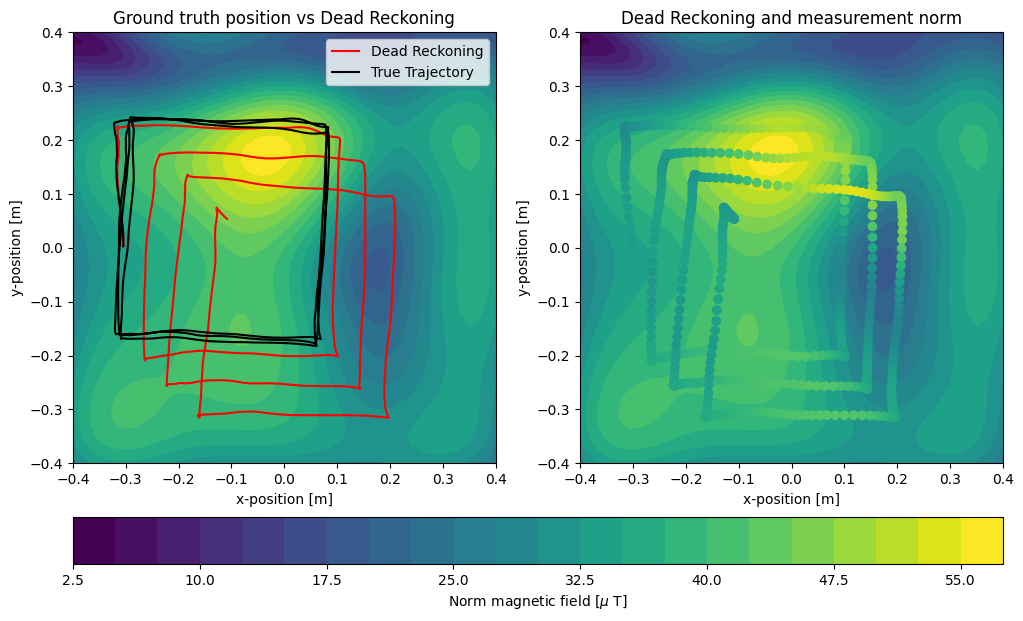

In [3]:
p = magnetometerInitialPosition.copy()
delta = deltaMagnetometerPositions.copy()
N = deltaMagnetometerPositions.shape[1]

deadReckoning = np.zeros((3,N))
for i in range(deltaMagnetometerPositions.shape[1]):
    p = (p + delta[:, i:i+1])
    deadReckoning[:,[i]] = p

magneticFieldNorm = (np.linalg.norm(magnetometerMeasurements,axis=0))

helper.makeDeadReckoningPlots(deadReckoning, magneticFieldNorm, modelParameters)

## EKF and UKF
To  use magnetometer measurements to reduce the positional drift observed in the figure above, besides PF in the previous lectures, you can also use EKF and UKF.

### EKF Implementation

You start from implementing EKF.  Your task is to fill in the following functions.

#### Task 1
Fill in the `dynamicUpdateEKF()` function according to the dynamic model given above. 

**Note:**
You do not have to change the inputs and outputs to the given functions.


In [4]:

def dynamicUpdateEKF(position, 
                   deltaPos, 
                   posCov, 
                   motionCovarianceEKF, 
                   modelParameters):
    ''' Dynamic update '''

    position = position + deltaPos
    posCov = posCov + motionCovarianceEKF

    # Alternative formulation using EKF conventions >>>>>>>>
    # F = np.eye(3) # Constant displacement 
    # posCov = F@(posCov)@(F).T + motionCovarianceEKF
    # <<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<

    return position, posCov

#### Task 2

Complete the function `measurementUpdateEKF()` according to the measurement model given above. 

To implement the measurement model, you will need to make predictions of the magnetic field. You DO NOT need to create this function yourself. To make predictions, use the function `GP.makeMagneticFieldPrediction(positions, modelParameters)` function make sure the input `positions` $\in \mathbb{R}^{3 \times 1} $. The output should be a matrix $\in \mathbb{R}^{3 \times 1}$ magnetic field predictions for every input location.  Similarly, to find the Jacobian, you muse use the GP.makeMagneticFieldJacobian(position, modelParameters) function make sure the input position is a vector of 3x1. The output should be a matrix of 3x3.

In [5]:
def measurementUpdateEKF(position, 
                         magnetometerMeasurement, 
                         posCov, 
                         measurementCovarianceEKF,
                         modelParameters):
    
    ''' Measurement update '''

    magneticFieldPrediction = GP.makeMagneticFieldPrediction(position, modelParameters) 
    jacobianMagneticFieldPrediction = GP.makeMagneticFieldJacobian(position, modelParameters)
    
    inv4K = np.linalg.inv(jacobianMagneticFieldPrediction @ posCov @ (jacobianMagneticFieldPrediction).T + measurementCovarianceEKF)

    K = posCov @ (jacobianMagneticFieldPrediction).T @ inv4K
    position = position + K @ (magnetometerMeasurement - magneticFieldPrediction)
    posCov = posCov - K @ jacobianMagneticFieldPrediction @ posCov

    return position, posCov, jacobianMagneticFieldPrediction

`extendedKalmanFilter()` is given as follows. You don't need to change it.

In [6]:
''' DO NOT CHANGE THE CODE BELOW '''

def extendedKalmanFilter(position, 
                         deltaPosition, 
                         magnetometerMeasurement, 
                         posCov, 
                         motionCovarianceEKF, 
                         measurementCovarianceEKF, 
                         modelParameters):
    ''' Estimates positions'''

    ''' Dynamic update '''    
    if modelParameters['NtimeStepEKF'] > 0:
        (position, 
         posCov) = dynamicUpdateEKF(position, 
                                  deltaPosition, 
                                  posCov, 
                                  motionCovarianceEKF,
                                  modelParameters)

    ''' Measurement update '''
    (position, 
     posCov, jacobianMagneticFieldPrediction) = measurementUpdateEKF(position,
                                    magnetometerMeasurement, 
                                    posCov, 
                                    measurementCovarianceEKF,
                                    modelParameters)

    return position, posCov, jacobianMagneticFieldPrediction

#### Task 3

Be sure to set the **initial position** and the **prior** on it correctly  and a **suitable measurement covariance** as you did in assignment 1.

You could start with the following parameters
- `motionCovarianceUKF` = np.eye(3)*0.001**2 
- `measurementCovarianceUKF` = np.eye(3)*1.5**2

Make sure `posCovarianceUKF` is a 3d tensor with the shape of `[3,3,NtimeSteps]`, to save the position covariances for every time step.
To get better results, you might have to tune these. 

In [7]:
''' Initialize the EKF '''
modelParameters['NtimeStepEKF'] = 0

motionCovarianceEKF = np.eye(3)*0.0035**2
measurementCovarianceEKF = np.eye(3)*3.**2

posEstEKF = np.zeros((3,712))
posEstEKF[:,0:1] = magnetometerInitialPosition
posCovarianceEKF = np.zeros((3,3,712))

# Inital position covariance: 
posCovarianceEKF[:, :, 0] = np.eye(3) * np.array((0.00045, 0.00048, 0.00015))
# print(f"InitCov:\n{posCovarianceEKF[:,:,0]}")

jacobian_history = np.zeros((3, 3, 712))

''' Run the EKF'''
for timendx in range(modelParameters['NtimeSteps']-1):
    deltaPosEKF = deltaMagnetometerPositions[:, timendx:timendx+1]
    ymeasEKF = magnetometerMeasurements[:, timendx:timendx+1]
    (posEstEKF[:, timendx+1:timendx+2], 
     posCovarianceEKF[:, :, timendx+1], jacobian_history[:,:, timendx+1]) = extendedKalmanFilter(posEstEKF[:, timendx:timendx+1], 
                                              deltaPosEKF, 
                                              ymeasEKF, 
                                              posCovarianceEKF[:, :, timendx],
                                              motionCovarianceEKF,
                                              measurementCovarianceEKF,
                                              modelParameters)
    modelParameters['NtimeStepEKF'] += 1


#### discussion

Elaborate on the effects of tuning the different variables:

- `motionCovarianceEKF`
- `measurementCovarianceEKF`
- The initial posiiton covariance `posCovarianceEKF[:, :, 0]`


1) `motionCovarianceEKF` - Changing this parameter had a large effect on our predictions, after crossing a threshold of approx $\ge 0.01^2$ large distortions in the EKF predicted path (`posEstEKF`) became apparent. This was attributed to the fact that we were injecting so much uncertainty in our dynamic estimate that the subsequent measurement update from the EKF then refined the estimate poorly (based on very large Kalman gain, from a large `posCov`), most likely further stressed by the multi-modal nature of the magnetic field. Which, conflicts with our Gaussian assumptions in the EKF. Besides this the variable increases the amount of covaraince in dynamic estimates, shown by the blue covariance circles expanding as we increase `motionCovarianceEKF`.

2) `measurementCovarianceEKF` - This parameter also had very notable effects on our estimated position and covariance. It was noted that as we increase the `measurementCovarianceEKF`, increasing our uncertainty in our measuremnt model, that the `posEstEKF` began to mirror `deadReckoning` trajectory. Intuitevely this make sense, as our uncertainty is so high in the measurement update that the EKF begins to discard the influence of measurements of the position estimate. Coversely, when arbitrarily decreasing the coavariance, the `posEstEKF` path became unstable, this again due to the multi-modality of the data. If we believe too singularly in our measurement, which infact can be represented by multiple different locations on the magnetic field, then our estimated path will become unstable (as seen). Therefore, a balance must be struck as it relates to the `measurementCovarianceEKF` to trust our dynamic model and reinforce it with our magnetometer data. 


3) `posCovarianceEKF[:, :, 0]` - It was noted that as long as the previous two parameters were correctly tuned, the initial position covariance had a minor effect on the predicition performance. The EKF was able to quickly minimize the variance in the first tens of seconds of the simulation. The only adverse effects it introduced is in our ability to analyze the system, given thean our inital covariance is very high (relative to the `motionCovarianceEKF` and `measurementCovarianceEKF`), the variations of covariance become untractable. As such, the intial covaraiance was selected to mirror the $cov(x)$, $cov(y)$, and $cov(z)$ peaks after tuning the `motionCovarianceEKF` and `measurementCovarianceEKF`, via a visual process of attempting the encapsulate the true path in our uncertain prediction path (encompass true path in blue covariance circles).


#### Visualize the output
<!-- TODO: keep or not. maybe comparison between EKF and UKF in the end is enough -->

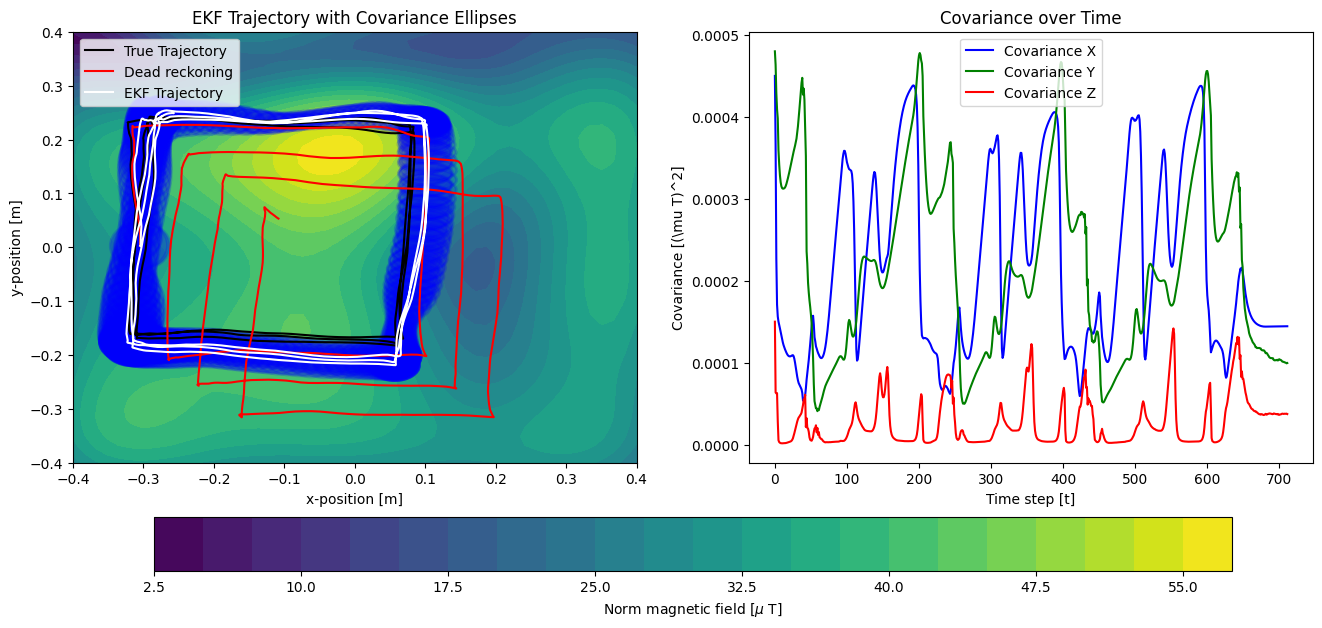

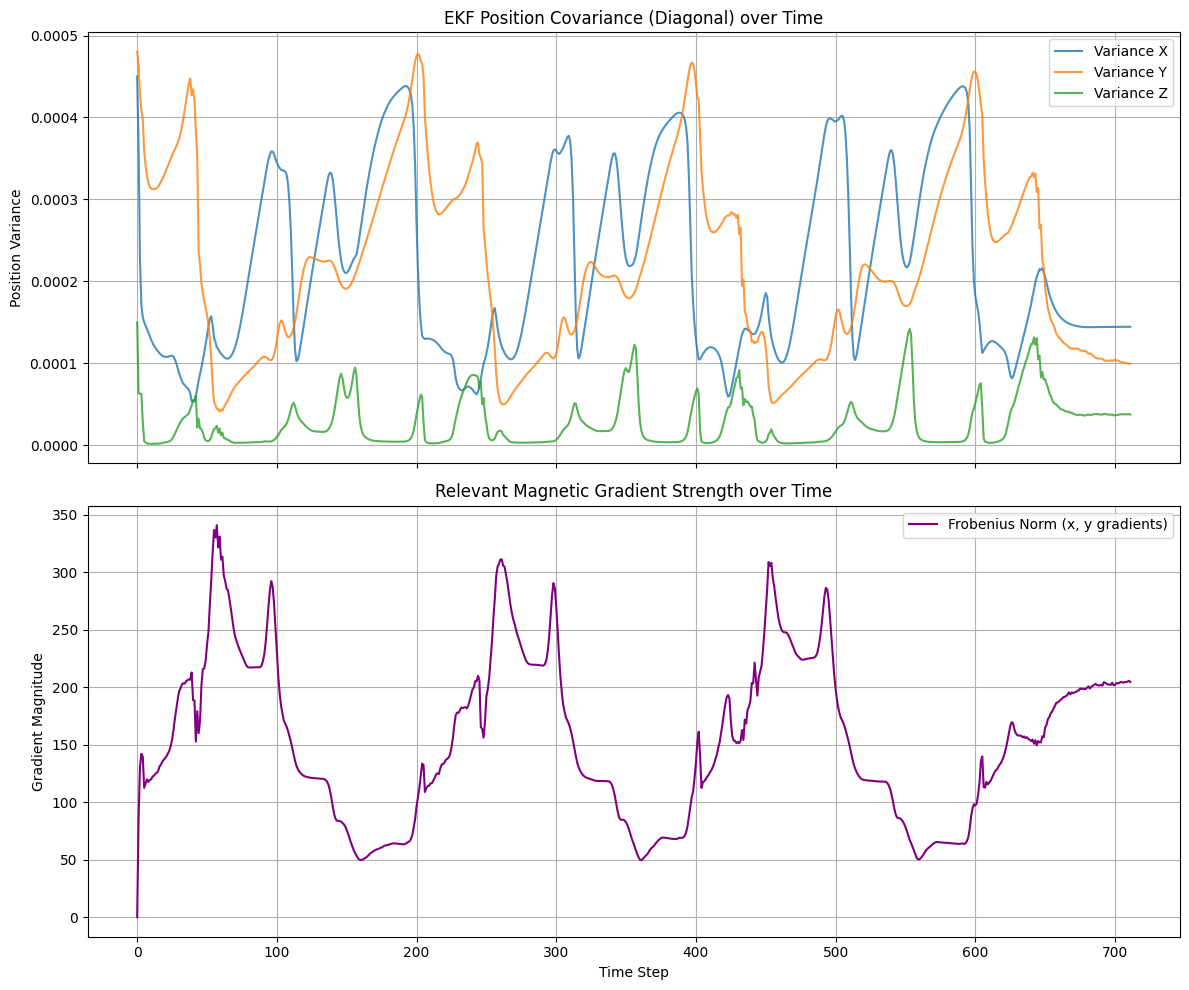

In [8]:
''' DO NOT CHANGE THE CODE BELOW '''
helper.makeExtendedKalmanFilterPlots(deadReckoning, posEstEKF, posCovarianceEKF, modelParameters)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
time_steps = np.arange(magnetometerMeasurements.shape[1])
# print(time_steps)
# 2. Position Variance
ax1.plot(time_steps, posCovarianceEKF[0, 0, :], label='Variance X', alpha=0.8)
ax1.plot(time_steps, posCovarianceEKF[1, 1, :], label='Variance Y', alpha=0.8)
ax1.plot(time_steps, posCovarianceEKF[2, 2, :], label='Variance Z', alpha=0.8)
ax1.set_ylabel('Position Variance')
ax1.set_title('EKF Position Covariance (Diagonal) over Time')
ax1.legend()
ax1.grid(True)

# 3. Jacobian Norm (x and y gradients only)
# Slice the first two columns (derivatives w.r.t x and y) and compute Frobenius norm
# jacobian_history shape: (3, 3, K) -> slice shape: (3, 2, K)
xy_jacobian = jacobian_history[:, :2, :]
jacobian_norm_xy = np.sqrt(np.sum(xy_jacobian**2, axis=(0, 1)))

ax2.plot(time_steps, jacobian_norm_xy, label='Frobenius Norm (x, y gradients)', color='purple')
ax2.set_xlabel('Time Step')
ax2.set_ylabel('Gradient Magnitude')
ax2.set_title('Relevant Magnetic Gradient Strength over Time')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()


**Discussion**

Explain why the covariance changes over time the way it does. You can create more plots if necessary for your analysis.

Above the following extra plots are included: the $(x,y,z)$ covariance, and the frobenius nrom of the jacobian (w.r.t to the x,y gradients), over a shared time scale. From here it is clearly seen that the $cov(x)$ and $cov(y)$ increases in regions where there is less magnetic field strength. This is a result of the "richness" of data in a specific area; when the jacobian norm is low, there is less dynamic information for the measurement update, and the EKF relies on the more heavily on the dynamic model, accumalating process uncertainty over time. When the jacobian norm is high, the agent is passing through an area with strong, and distint magnetic gradients, as such the EKF recieved high-qaulity localization data and updates more confidently. 

### UKF implement 

#### Task 1
Fill in the `dynamicUpdateUKF()` function according to the dynamic model given above. 

#### Note:
You do not have to change the inputs and outputs to the given functions.


In [9]:
def dynamicUpdateUKF(position, 
                   deltaPos, 
                   posCov, 
                   motionCovarianceUKF, 
                   modelParameters):
    ''' Dynamic update '''
    position = position + deltaPos
    
    posCov = posCov + motionCovarianceUKF

    return position, posCov

#### Task 2

- Complete creating sigma points `createSigmaPoints()` and calculating sigma weights `calculateSigmaWeights()`.
- Fill in the `measurementUpdateUKF()` according to the measurement model given above. 
- You can play around with UT1 and UT2, can you see any obvious differences?


In [149]:
def createSigmaPoints(stateVector, 
                      stateCovariance, 
                      lamdaWeights,
                      modelParameters):
    ''' Create sigma points '''
    n = 3
    sigmaPoints = np.zeros((n,2*n+1))
    U, S, V = np.linalg.svd(stateCovariance)
    rP = U @ np.diag(np.sqrt(S))
    sigmaPoints[:, [0]] = stateVector  
    for i in range(n):
        sigmaPoints[:, [i+1]] = stateVector + np.sqrt(n+lamdaWeights)*rP[:, [i]]
        sigmaPoints[:, [i+1+n]] = stateVector - np.sqrt(n+lamdaWeights)*rP[:, [i]]

    return sigmaPoints


def calculateSigmaWeights(UTnumber = 2):
    ''' Calculate the weights '''
    n = 3
    if UTnumber == 1:
        '''UT1'''
        lamdaWeights = 3-n
        weightsMean1 = lamdaWeights/(n + lamdaWeights)
        weightsMeanRest = 1/(2*(n+lamdaWeights))
        weightsCov1 = lamdaWeights/(n + lamdaWeights)
        weightsCovRest = 1/(2*(n+lamdaWeights))
        weightsMean = np.zeros(2*n+1)
        weightsMean[0] = weightsMean1
        weightsCov = np.zeros(2*n+1)
        weightsCov[0] = weightsCov1
        for i in range(weightsCov.shape[0]-1):
            weightsMean[i+1] = weightsMeanRest
            weightsCov[i+1] = weightsCovRest
            

    else:
        '''UT2'''
        lamdaWeights = 10**(-6)
        weightsMean1 = lamdaWeights/(n + lamdaWeights)
        weightsMeanRest = 1/(2*(n+lamdaWeights))
        weightsCov1 = lamdaWeights/(n + lamdaWeights) + 3- 10**(-6)
        weightsCovRest = 1/(2*(n+lamdaWeights))
        weightsMean = np.zeros(2*n+1)
        weightsMean[0] = weightsMean1
        weightsCov = np.zeros(2*n+1)
        weightsCov[0] = weightsCov1
        for i in range(weightsCov.shape[0]-1):
            weightsMean[i+1] = weightsMeanRest
            weightsCov[i+1] = weightsCovRest
      
    return lamdaWeights, weightsMean, weightsCov


def measurementUpdateUKF(position,
                         magnetometerMeasurement,
                         posCovariance,
                         measurementCovarianceUKF,
                         lamdaWeights, 
                         weightsMean, 
                         weightsCovariance,
                         modelParameters):
    
    ''' Measurement update '''
    n = 3
    sigmaPoints = createSigmaPoints(position, posCovariance, lamdaWeights, modelParameters)

    ySigma =  GP.makeMagneticFieldPrediction(sigmaPoints, modelParameters) 

    yEst = np.zeros((3,1))
    Ck = np.zeros((3,3))
    Sk = np.zeros((3,3))
    
    for i in range(2*n + 1): 
        yEst += weightsMean[i]*ySigma[:,[i]]
        Ck += weightsCovariance[i] * (sigmaPoints[:,[i]] - position) @ (ySigma[:,[i]] - yEst).T
        Sk += weightsCovariance[i] * (ySigma[:,[i]] - yEst) @  (ySigma[:,[i]] - yEst).T  
        
    Sk += measurementCovarianceUKF
    Kk = Ck @ np.linalg.inv(Sk)
    position = position + Kk @ (magnetometerMeasurement - yEst)
    posCovariance = posCovariance - Kk@Sk@Kk.T

    return position, posCovariance

`unscentedKalmanFilter()` is given as follows. You don't need to change it.

In [150]:
''' DO NOT CHANGE THE CODE BELOW '''
def unscentedKalmanFilter(position, 
                          deltaPos, 
                          magnetometerMeasurement, 
                          posCovariance, 
                          motionCovarianceUKF,
                          measurementCovarianceUKF,
                          lamdaWeights, 
                          weightsMean, 
                          weightsCovariance,
                          modelParameters):

    if modelParameters['NtimeStepUKF'] > 0:
        ''' State update '''
        position, posCovariance = dynamicUpdateUKF(position, 
                                                deltaPos, 
                                                posCovariance, 
                                                motionCovarianceUKF, 
                                                modelParameters)

    ''' Measurement update '''
    position, posCovariance = measurementUpdateUKF(position, 
                                                   magnetometerMeasurement, 
                                                   posCovariance, 
                                                   measurementCovarianceUKF,
                                                   lamdaWeights,
                                                   weightsMean,
                                                   weightsCovariance,
                                                   modelParameters)

    return position, posCovariance



#### Task 3

Be sure to set the **initial position** and the **prior** on it correctly  and a **suitable measurement covariance** as you did in assignment 1.

You could start with the following parameters
- `motionCovarianceUKF` = np.eye(3)*0.001**2 
- `measurementCovarianceUKF` = np.eye(3)*1.5**2

Make sure `posCovarianceUKF` is a 3d tensor with the shape of `[3,3,NtimeSteps]`, to save the position covariances for every time step.
To get better results, you might have to tune these. 

In [175]:

''' Initialize the UKF '''
modelParameters['NtimeStepUKF'] = 0

motionCovarianceUKF = np.eye(3)*0.000005
measurementCovarianceUKF = np.eye(3)*10
posEstUKF = np.zeros((3,712))
posEstUKF[:,0:1] = magnetometerInitialPosition
posCovarianceUKF = np.zeros((3,3,modelParameters['NtimeSteps']))
posCovarianceUKF[:, :, 0] = np.eye(3)*0.0000000000001

lamdaWeights, weightsMean, weightsCovariance = calculateSigmaWeights()
''' Run the UKF'''
for timendx in range(modelParameters['NtimeSteps']-1):
    (posEstUKF[:, timendx+1:timendx+2], 
     posCovarianceUKF[:, :, timendx+1]) = unscentedKalmanFilter(posEstUKF[:, timendx:timendx+1], 
                                               deltaMagnetometerPositions[:, timendx:timendx+1], 
                                               magnetometerMeasurements[:, timendx:timendx+1], 
                                               posCovarianceUKF[:, :, timendx],
                                               motionCovarianceUKF,
                                               measurementCovarianceUKF,
                                               lamdaWeights, 
                                               weightsMean, 
                                               weightsCovariance,
                                               modelParameters)
    modelParameters['NtimeStepUKF'] += 1

posCovarianceEKF = np.zeros((3, 3, modelParameters['NtimeSteps']))
posCovarianceEKF[:,:,0] = np.eye(3)*0


#### discussion

Elaborate on the effects of tuning the different variables:

- `motionCovarianceUKF`
- `measurementCovarianceUKF`
- The initial posiiton covariance `posCovarianceUKF[:, :, 0]`

Is it different from tuning the variables for the EKF?


For the UT1, tuning these variables has to be very precise; typical tuning variations (magnitude 10 changes) have very big effects on how well the model works. We had to tune it perfectly in order to make the UKF work well in estimating the position of the magnetometer. This is true for all three of the covariances we can tune. For UK2, there is slightly less influence of the tuning of the covariances; the motion covariance and measurement covariance particularly have less influence. This may be as the range of the sigma points is smaller, meaning that they are more "stable", as in small variations impact them less than for sigma points far away from the central sigma point (prior estimate). The initial position covariance however has to be kept under a certain bound, or else the filter will not work. This is quite different to the EKF, where you can tweak the covariances with a bigger degree of freedom.

Motion Covariance: Increasing this beyond a certain threshold leads to the filter breaking down. Specifically, we see that the effects only hit after a certain amount of time passes, showing that the filter is no longer able to compensate for a high uncertainty after longer periods.

Measurement Covariance: In a similar way to the EKF, when the measurement covariance is too high, the filter recreates the "dead reckoning" movement. This is because the model no longer uses the estimates (the measurement covariance goes into S_k, which decreases the Kalman gain, and decreases how much the estimate is used).

Initial position covariance: it was found that increasing it beyond a certain point ruins the filter (as already stated). However, if it was decreased to be close to 0, the filter also replicated the movement of the dead reckoning estimate.

### compare EKF and UKF
#### Visualize the output

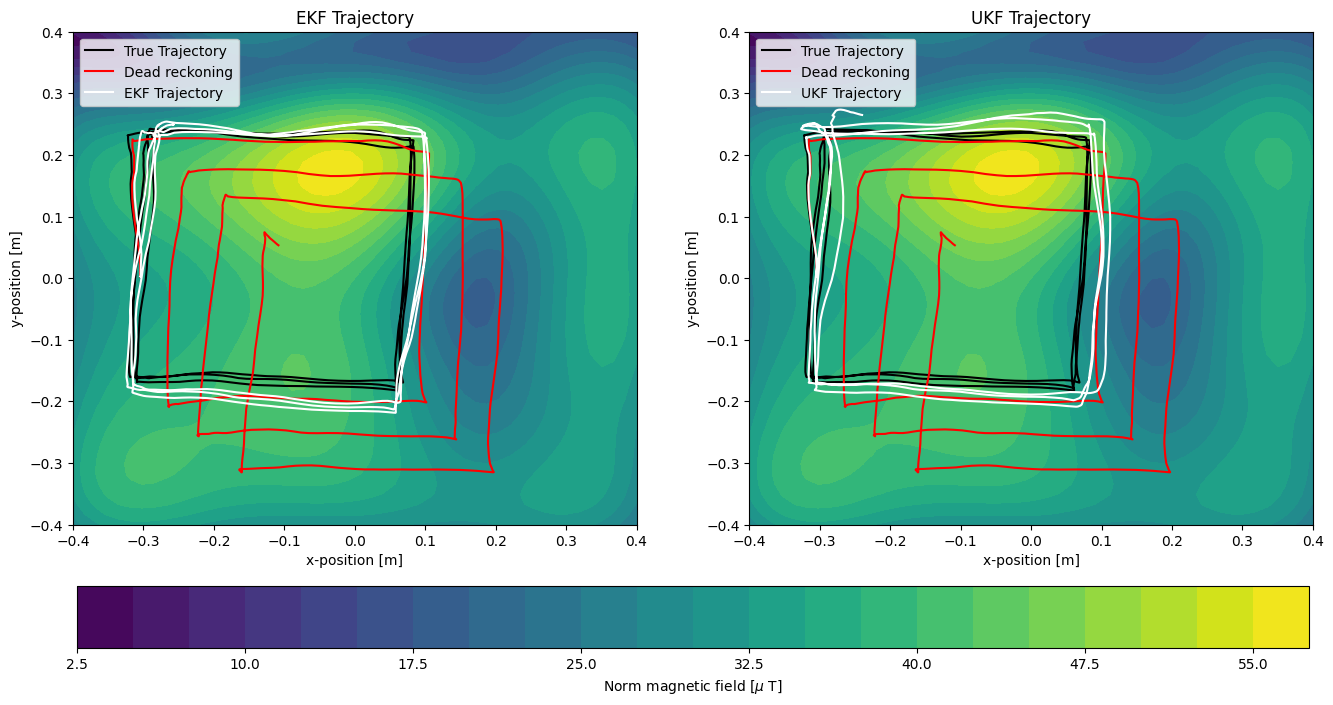

In [176]:
helper.makeKalmanFilterPlots(deadReckoning, posEstEKF, posEstUKF, modelParameters)

#### Discussion
Elaborate on the two plots.
- Compare the results from the UKF with the EKF? Does one provide better results? Elaborate!
- Comment on the reason for choosing either EKF, UKF of PF for this non-linear estimation problem. Also relate this to the results from assignment 1. 
- In what type of estimation problems would you expect to see very different results for the EKF, UKF and PF? 


1) Both the UKF and the EKF have satisfactory (if not good!) results. However there are small differences between the two. First of all, the EKF is much more consistent with past cycles (when the magnetometer arrives to the same spot); the UKF has more variance in each cycle. However, the UKF Tends to have much less error in certain parts of the cycle, for example in the bottom part of the square. Overall, the results are almost equal, if not a bit better for the EKF. This may be because of the magnetic field not being highly nonlinear. 

2) The EKF should be chosen for this problem; it is well suited for a not-very-nonlinear estimation problem. All of the methods provide a good results, the particle filter also having excellent results with enough particles. However, the EKF provides good results with a fraction of the time the particle filter takes (the EKF is also about 6x faster than the UKF, which might become relevant in high-dimensionality problems that require more sigma points).

#### Discussion
Elaborate on the two plots.
- Compare the results from the UKF with the EKF? Does one provide better results? Elaborate!
- Comment on the reason for choosing either EKF, UKF of PF for this non-linear estimation problem. Also relate this to the results from assignment 1. 
- In what type of estimation problems would you expect to see very different results for the EKF, UKF and PF? 

1) Both the UKF and the EKF have satisfactory (if not good!) results. However there are small differences between the two. First of all, the EKF is much more consistent with past cycles (when the magnetometer arrives to the same spot); the UKF has more variance in each cycle. However, the UKF Tends to have much less error in certain parts of the cycle, for example in the bottom part of the square. Overall, the results are almost equal, if not a bit better for the EKF. This may be because of the magnetic field not being highly nonlinear. 

2) The EKF should be chosen for this problem; it is well suited for a not-very-nonlinear estimation problem. All of the methods provide a good results, the particle filter also having excellent results with enough particles. However, the EKF provides good results with a fraction of the time the particle filter takes (the EKF is also about 6x faster than the UKF, which might become relevant in high-dimensionality problems that require more sigma points).

3) There are two distinguishing characteristic of an arbitrary estimatation problem that would result in very different results betwen EKF and UKF, and Particle Filter (PF). This being the how non-linear the dynamics of the model are, how gaussian the posterior used in the measurement model is and size of the state-space.
EKF, and UKF use approximations of non-linear behavioure (first-order gradient, and sigma-points), and as such will poorer performance in estimattion problem with more non-linearity in the state-space representation of the system. Conversely, as the PF directly samples from the state-space, and it negates the drawbacks of the EKF and UKF in these context. Similarly as it relates to how Gaussian the posterior is, PF is suited for multi-modal examples due it's exact sampling nature, wheras EKF and UKF, expect and Gaussian posterior, and perform worse in multi-modal contexts.
When the state-space is excessively large, or computational resources are limited. The PF will become limited in applicaiton. As we need to sample, and resample a large number of discrete points, in n-dimensional space the computational complexity of PF scales with $\mathcal{O}(N\times n^2)$, with $N$ being the number of particles, and $N >> n$ typically. This compared to $\mathcal{O}(n^3)$ for EKF and UKF, PF will have to limit the number of particles in copmutationally constrained contexts, resulting in less accurate estimation, comparatively although EKF and UKF might be poorer at handling non-linearies, they would still out perform a limited PF in these cases.